In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


In [2]:
# Sampling frequency
fs = 1000  

# Cutoff frequency
fc = 100  

# Normalize frequency
w = fc / (fs/2)

# Filter order
N = 4  

# Ripple (in dB)
rp = 1  

In [3]:
b, a = signal.cheby1(N, rp, w, btype='low', analog=False)

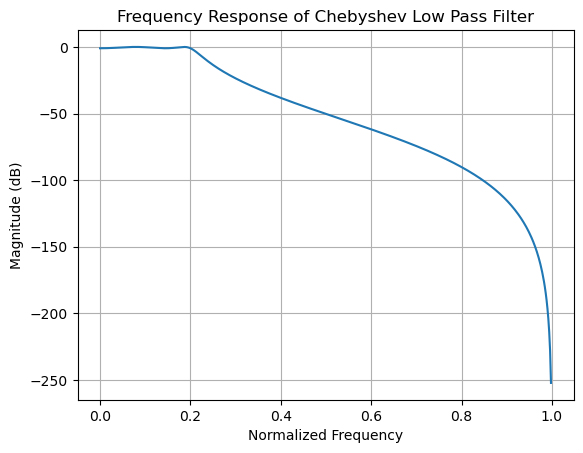

In [4]:
w, h = signal.freqz(b, a)

plt.figure()
plt.plot(w/np.pi, 20*np.log10(abs(h)))
plt.title("Frequency Response of Chebyshev Low Pass Filter")
plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

In [5]:
t = np.linspace(0, 1, fs)

# Low freq signal
x1 = np.sin(2*np.pi*50*t)

# High freq noise
x2 = np.sin(2*np.pi*300*t)

# Combined signal
x = x1 + x2

In [6]:
y = signal.lfilter(b, a, x)

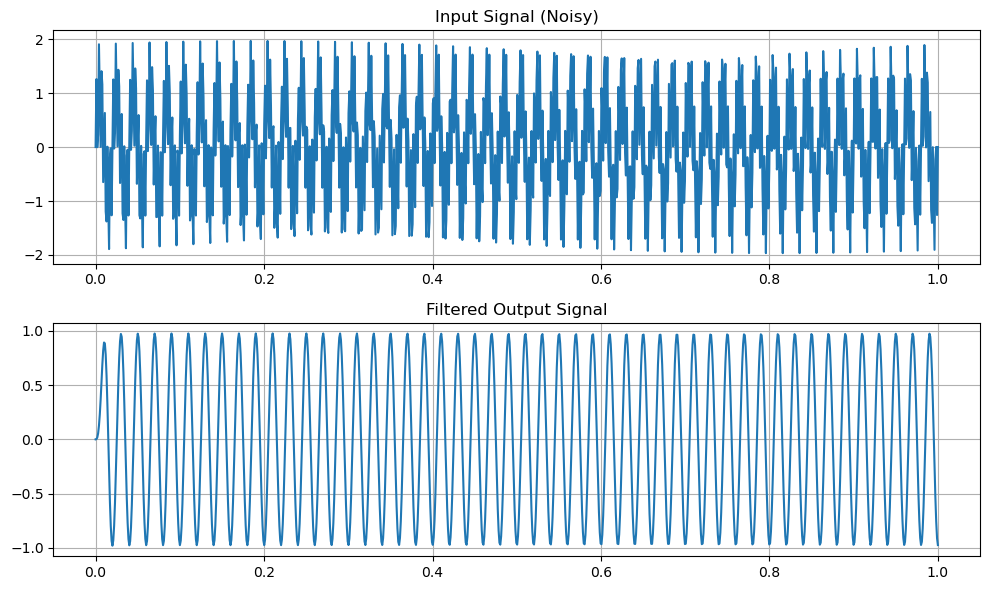

In [7]:
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t, x)
plt.title("Input Signal (Noisy)")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, y)
plt.title("Filtered Output Signal")
plt.grid()

plt.tight_layout()
plt.show()